%pip install gTTS

%pip install playsound==1.2.2

In [96]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import face_recognition
from scipy.spatial import distance
import warnings
from gtts import gTTS
from playsound import playsound
import time
import threading
warnings.filterwarnings('ignore')

In [97]:
image_path1 = 'test1.jpg'
image1 = Image.open(image_path1)

In [98]:
image_path2 = 'test2.png'
image2 = Image.open(image_path2)

In [99]:
image_path3 = 'test3.png'
image3 = Image.open(image_path3)

In [100]:
def highlight_facial_points(image_path, dot_size):
    # load the image
    image_bgr = cv2.imread(image_path)
    # convert from bgr to rgb
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # detect faces in the image
    face_locations=face_recognition.face_locations(image_rgb, model='hog')

    for face_location in face_locations:
        # get facial landmarks
        landmarks = face_recognition.face_landmarks(image_rgb, [face_location])[0]

        # Iterate over the facial landmarks and draw them on the image
        for landmark_type, landmark_points in landmarks.items():
            for (x, y) in landmark_points:
                cv2.circle(image_rgb, (x, y), dot_size, (0, 255, 0), -1)

    # plot the image with highlighted facial points
    plt.figure(figsize=(6, 6))
    plt.imshow(image_rgb)
    plt.axis('on')
    plt.show()

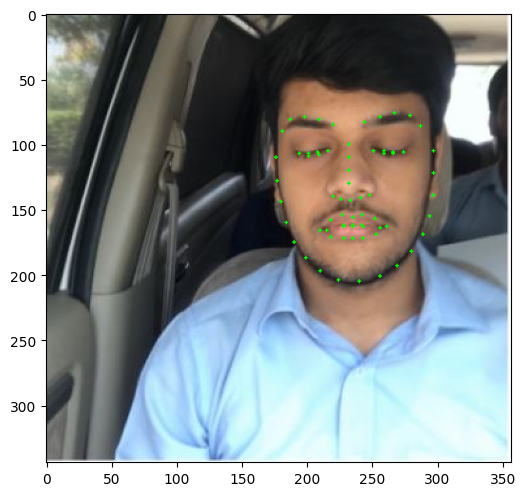

In [101]:
highlight_facial_points(image_path1, 1)

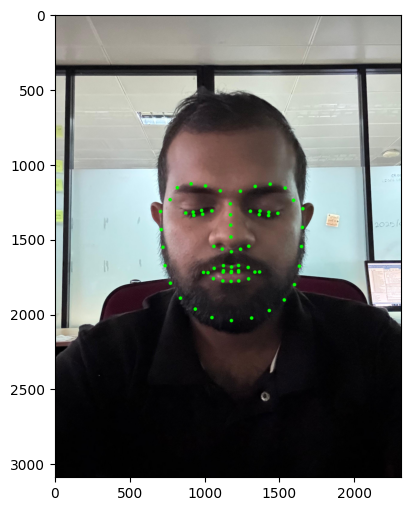

In [116]:
highlight_facial_points(image_path2, 12)

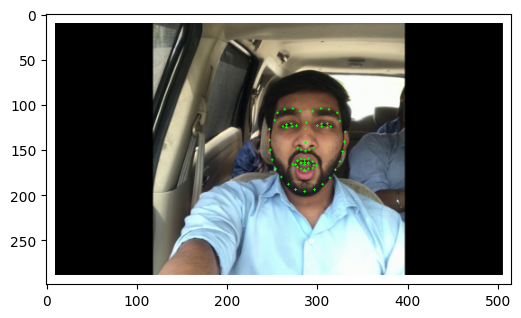

In [103]:
highlight_facial_points(image_path3, 1)

In [104]:
# calculate eye aspect ratio
def eye_aspect_ratio(eye):
    A = distance.euclidean(eye[1], eye[5])
    B = distance.euclidean(eye[2], eye[4])
    C = distance.euclidean(eye[0], eye[3])
    ear = (A+B) / (2.0 * C)
    return ear

In [105]:
# calculate mount aspect ratio
def mouth_aspect_ratio(mouth):
    A = distance.euclidean(mouth[2], mouth[10])  # roughly upper/lower near left-center
    B = distance.euclidean(mouth[4], mouth[8])   # roughly upper/lower near right-center
    C = distance.euclidean(mouth[0], mouth[6])   # left-right mouth corners (width)
    return (A + B) / (2.0 * C)

In [106]:
# Configurable thresholds
EYE_AR_THRESH = 0.23       # EAR threshold for closed eyes
MOUTH_AR_THRESH = 0.25      # MAR threshold for yawning
EYE_CLOSED_TIME = 2      # Seconds eyes must be continuously closed
MOUTH_OPEN_TIME = 2.5      # Seconds mouth must be continuously open

# Cooldown to prevent repeated TTS
ALERT_COOLDOWN = 5         # seconds

# Global variables to track
eye_closed_start = None
mouth_open_start = None
last_alert_time = 0

In [107]:
# Resize the image before processing to improve performance
def process_image(frame):
    """
    Process one frame:
    - Detect face landmarks
    - Compute Eye Aspect Ratio (EAR)
    - Compute Mouth Aspect Ratio (MAR)
    - Return eye_closed (bool), mouth_open (bool)
    """
    if frame is None:
        raise ValueError("Frame is empty or invalid.")

    # ---- Convert to RGB for face_recognition ----
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # ---- Detect face locations ----
    face_locations = face_recognition.face_locations(rgb_frame, model="hog")

    # Flags
    eye_closed = False
    mouth_open = False

    if not face_locations:
        return False, False, None, None, None


    for face_location in face_locations:
        try:
            # Get facial landmarks
            landmarks_list = face_recognition.face_landmarks(rgb_frame, [face_location])
            if not landmarks_list:
                continue

            landmarks = landmarks_list[0]

            # Ensure required features exist
            if not all(k in landmarks for k in ["left_eye", "right_eye", "top_lip", "bottom_lip"]):
                continue

            # Convert to numpy arrays
            left_eye = np.array(landmarks["left_eye"])
            right_eye = np.array(landmarks["right_eye"])

            # Combine top & bottom lip landmarks (for outer contour)
            mouth_points = np.array(landmarks["top_lip"] + landmarks["bottom_lip"][::-1])

            # # Top lip: first 6 points (outer)
            # top_lip_outer = landmarks["top_lip"][:6]
            # # Bottom lip: first 6 points (outer), reversed for clockwise order
            # bottom_lip_outer = landmarks["bottom_lip"][:6][::-1]
            # # Combine into 12 points for MAR
            # mouth_points = np.array(top_lip_outer + bottom_lip_outer)

            # ---- Compute EAR & MAR ----
            left_ear = eye_aspect_ratio(left_eye)
            right_ear = eye_aspect_ratio(right_eye)
            ear = (left_ear + right_ear) / 2.0
            mar = mouth_aspect_ratio(mouth_points[:12])

            # ---- Determine Drowsiness Indicators ----
            if ear < EYE_AR_THRESH:
                eye_closed = True

            if mar > MOUTH_AR_THRESH:
                mouth_open = True

            # ---- Visualization (optional) ----
            # visualize_landmarks(frame, landmarks)

            # Display EAR & MAR on screen
            cv2.putText(frame, f"EAR: {ear:.3f}", (30, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
            cv2.putText(frame, f"MAR: {mar:.3f}", (30, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

        except Exception as e:
            print(f"[WARN] Error processing landmarks: {e}")
            continue

    return eye_closed, mouth_open, mouth_points, left_eye, right_eye

In [108]:
img1 = cv2.imread(image_path1)
process_image(img1)

(True,
 False,
 array([[210, 166],
        [218, 158],
        [227, 154],
        [235, 156],
        [242, 154],
        [252, 157],
        [261, 163],
        [256, 164],
        [242, 162],
        [235, 162],
        [228, 162],
        [215, 166],
        [256, 164],
        [243, 163],
        [235, 163],
        [228, 163],
        [215, 166],
        [210, 166],
        [218, 171],
        [228, 172],
        [235, 172],
        [243, 172],
        [253, 169],
        [261, 163]]),
 array([[194, 107],
        [201, 107],
        [208, 106],
        [216, 105],
        [209, 108],
        [201, 109]]),
 array([[251, 105],
        [259, 105],
        [266, 106],
        [274, 106],
        [266, 107],
        [259, 107]]))

In [109]:
img2 = cv2.imread(image_path2)
process_image(img2)

(True,
 False,
 array([[ 991, 1720],
        [1062, 1693],
        [1124, 1675],
        [1178, 1684],
        [1225, 1674],
        [1289, 1687],
        [1365, 1717],
        [1334, 1718],
        [1225, 1709],
        [1177, 1714],
        [1124, 1709],
        [1021, 1722],
        [1334, 1718],
        [1225, 1717],
        [1176, 1721],
        [1122, 1718],
        [1021, 1722],
        [ 991, 1720],
        [1057, 1762],
        [1120, 1777],
        [1175, 1780],
        [1226, 1777],
        [1292, 1763],
        [1365, 1717]]),
 array([[ 872, 1323],
        [ 922, 1317],
        [ 978, 1306],
        [1047, 1309],
        [ 985, 1331],
        [ 926, 1339]]),
 array([[1304, 1311],
        [1368, 1310],
        [1427, 1318],
        [1487, 1325],
        [1425, 1340],
        [1363, 1334]]))

In [110]:
img3 = cv2.imread(image_path3)
process_image(img3)

(True,
 False,
 array([[273, 166],
        [278, 162],
        [282, 160],
        [286, 161],
        [290, 160],
        [295, 163],
        [299, 167],
        [296, 167],
        [290, 164],
        [286, 164],
        [282, 164],
        [276, 166],
        [296, 167],
        [290, 165],
        [286, 166],
        [282, 165],
        [276, 166],
        [273, 166],
        [278, 169],
        [282, 171],
        [286, 172],
        [290, 171],
        [295, 170],
        [299, 167]]),
 array([[262, 124],
        [266, 122],
        [271, 121],
        [277, 123],
        [272, 124],
        [266, 125]]),
 array([[300, 123],
        [305, 121],
        [311, 121],
        [315, 124],
        [311, 125],
        [305, 124]]))

In [111]:
def text_to_speech(text):
    def _play_sound(text_inner):
        try:
            tts = gTTS(text=text_inner, lang='en')
            filename = "alert.mp3"
            tts.save(filename)
            playsound(filename)
            os.remove(filename)
        except Exception as e:
            print(f"[TTS Error] {e}")

    # Run TTS in a separate thread
    t = threading.Thread(target=_play_sound, args=(text,))
    t.daemon = True  # ensures thread exits when main program exits
    t.start()

In [112]:
def real_time_detection():
    global eye_closed_start, mouth_open_start, last_alert_time
    cap = cv2.VideoCapture(0)

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            eye_closed, mouth_open, mouth_points, left_eye, right_eye = process_image(frame)
            current_time = time.time()

            # # Draw mouth points
            # if mouth_points is not None:
            #     for (x, y) in mouth_points:
            #         cv2.circle(frame, (x, y), 2, (0, 255, 0), -1)

            # Draw mouth contour
            if mouth_points is not None:
                for i in range(len(mouth_points)):
                    start_point = tuple(mouth_points[i])
                    end_point = tuple(mouth_points[(i + 1) % len(mouth_points)])
                    cv2.line(frame, start_point, end_point, (0, 255, 255), 2)
            # Draw left eye
            if left_eye is not None:
                for i in range(len(left_eye)):
                    start_point = tuple(left_eye[i])
                    end_point = tuple(left_eye[(i + 1) % len(left_eye)])
                    cv2.line(frame, start_point, end_point, (255, 0, 0), 2)
            # Draw right eye
            if right_eye is not None:
                for i in range(len(right_eye)):
                    start_point = tuple(right_eye[i])
                    end_point = tuple(right_eye[(i + 1) % len(right_eye)])
                    cv2.line(frame, start_point, end_point, (255, 0, 0), 2)

            # ---- Eye Drowsiness Scoring ----
            if eye_closed:
                if eye_closed_start is None:
                    eye_closed_start = current_time  # Start counting
                elif current_time - eye_closed_start >= EYE_CLOSED_TIME:
                    # Trigger alert if cooldown passed
                    if current_time - last_alert_time >= ALERT_COOLDOWN:
                        text_to_speech("Drowsiness detected, please wake up!")
                        last_alert_time = current_time
                    cv2.putText(frame, "DROWSY!", (30, 110), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 3)
            else:
                eye_closed_start = None  # Reset counter

            # ---- Yawning Scoring ----
            if mouth_open:
                if mouth_open_start is None:
                    mouth_open_start = current_time
                elif current_time - mouth_open_start >= MOUTH_OPEN_TIME:
                    if current_time - last_alert_time >= ALERT_COOLDOWN:
                        text_to_speech("Yawning detected, please take a rest.")
                        last_alert_time = current_time
                    cv2.putText(frame, "YAWNING!", (30, 140), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 3)
            else:
                mouth_open_start = None

            # Display EAR/MAR (optional)
            # cv2.putText(frame, f"EAR: {ear:.2f}", (30, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
            # cv2.putText(frame, f"MAR: {mar:.2f}", (30, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

            cv2.imshow("SafeDriver Monitor", frame)
            if cv2.waitKey(1) & 0xFF == 27:  # ESC to exit
                break

    except Exception as e:
        print(f"[ERROR] {e}")

    finally:
        cap.release()
        cv2.destroyAllWindows()

In [113]:
real_time_detection()